
---

# ***`EDA using Bivariate and Multivariate Analysis`***

---

#### **Importing Libraries** 

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

#### **Load the datasets**

In [2]:
iris = sns.load_dataset("iris")
tips = sns.load_dataset("tips")
flights = sns.load_dataset("flights")
titanic = pd.read_csv(r"E:\Data Science Materials\100 days of Machine Learning CampusX\data\titanic_train.csv")

In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


#### **1. Scatter Plot (Numerical - Numerical)**

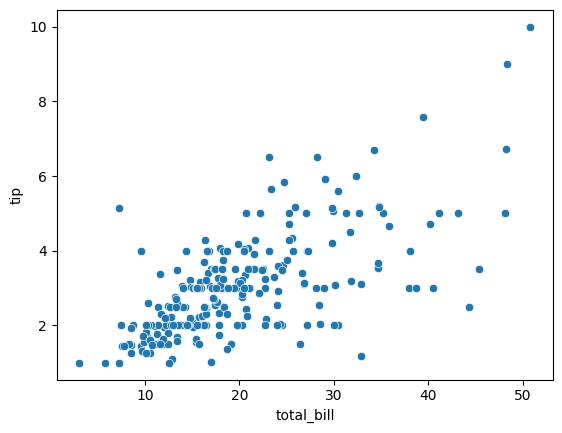

In [4]:
sns.scatterplot(data=tips,x="total_bill",y="tip") # bivariate 
plt.show()

- There is a linear relationship between `tip` and `total_bill`.

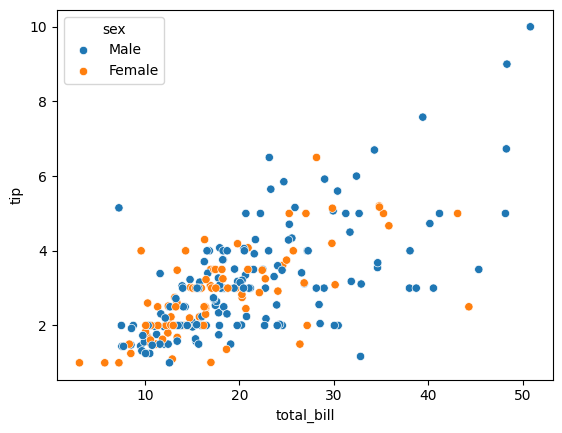

In [5]:
sns.scatterplot(data=tips,x="total_bill",y="tip",hue="sex") # multivariate 
plt.show()

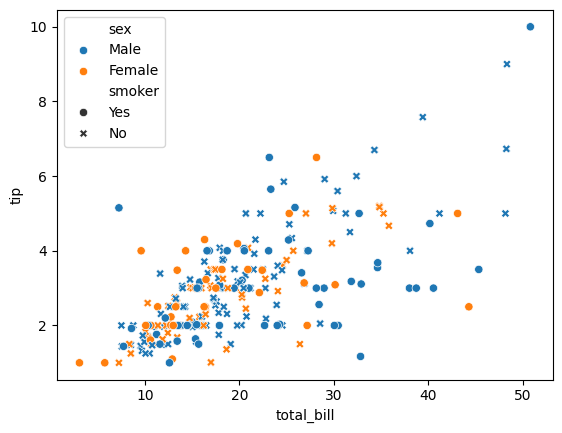

In [6]:
sns.scatterplot(data=tips,x="total_bill",y="tip",hue="sex",style="smoker") # multivariate 
plt.show()

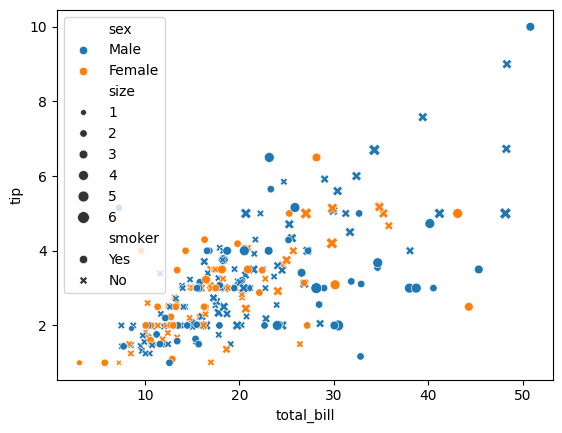

In [7]:
sns.scatterplot(data=tips,x="total_bill",y="tip",hue="sex",style="smoker",size="size") # multivariate 
plt.show()

#### **2. Bar Plot (Numerical - Categorical)**


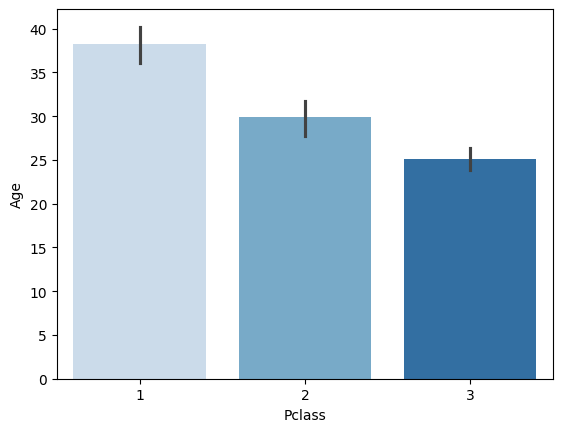

In [19]:
# relationship between the `Pclass` and `Age` of customer
sns.barplot(data=titanic,x="Pclass",y="Age",palette="Blues") 
plt.show()

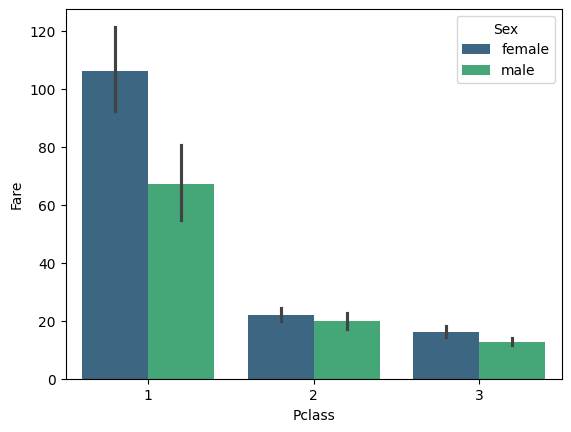

In [18]:
# relationship between the `Pclass` and `Fare` of customer
sns.barplot(data=titanic,x="Pclass",y="Fare",hue="Sex",palette="viridis")  
plt.show()

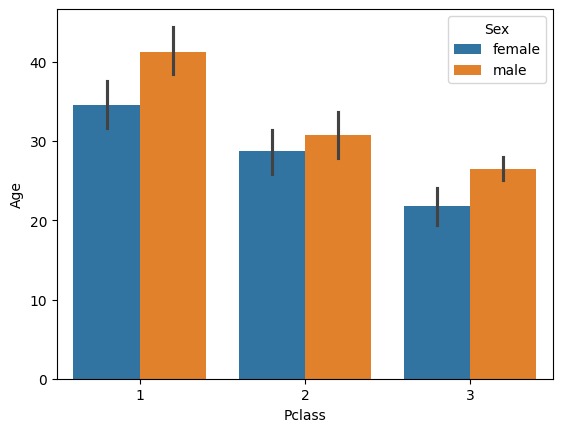

In [ ]:
# relationship between the `Pclass` and `Age` of customer
sns.barplot(data=titanic,x="Pclass",y="Age",hue="Sex")  
plt.show()

#### **3. Box Plot (Numerical - Categorical)**


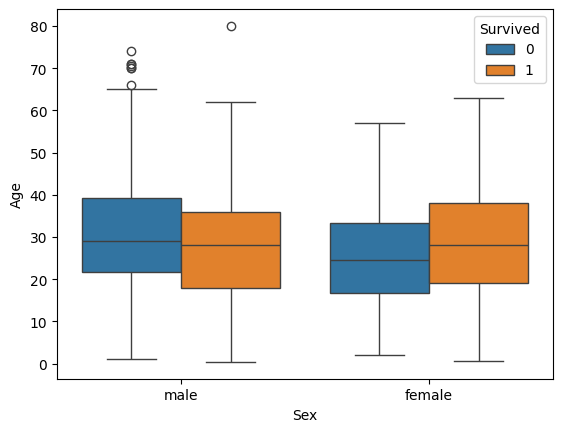

In [24]:
# relationship between the `Sex` and `Age` of customer
sns.boxplot(data=titanic,x="Sex",y="Age",hue="Survived")  
plt.show()

#### **4. Heatmap (Categorical - Categorical)**


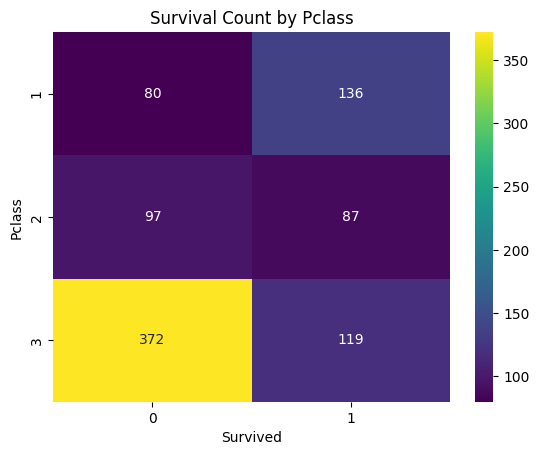

In [32]:
# Create a crosstab and display it as a heatmap
sns.heatmap(pd.crosstab(titanic['Pclass'], titanic['Survived']), 
            cmap="viridis", annot=True, fmt="d")

plt.title("Survival Count by Pclass")
plt.xlabel("Survived")
plt.ylabel("Pclass")
plt.show()

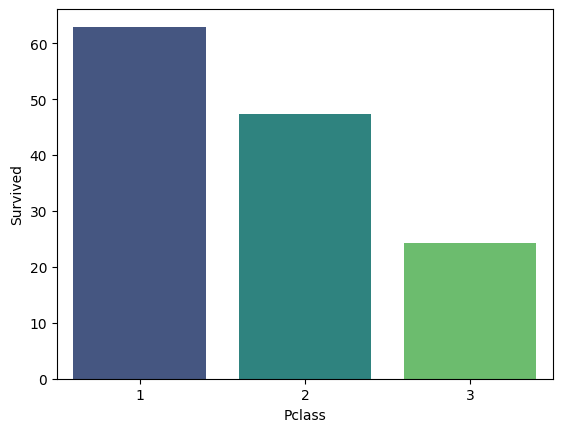

In [38]:
# Convert 'Survived' column to numeric if it's not already
titanic['Survived'] = pd.to_numeric(titanic['Survived'], errors='coerce')

# Calculate the percentage of people who survived by Pclass
survival_percentage = titanic.groupby("Pclass")['Survived'].mean() * 100

sns.barplot(data=survival_percentage,palette="viridis")
plt.show()

#### **5. Clustermap (Categorical - Categorical)**


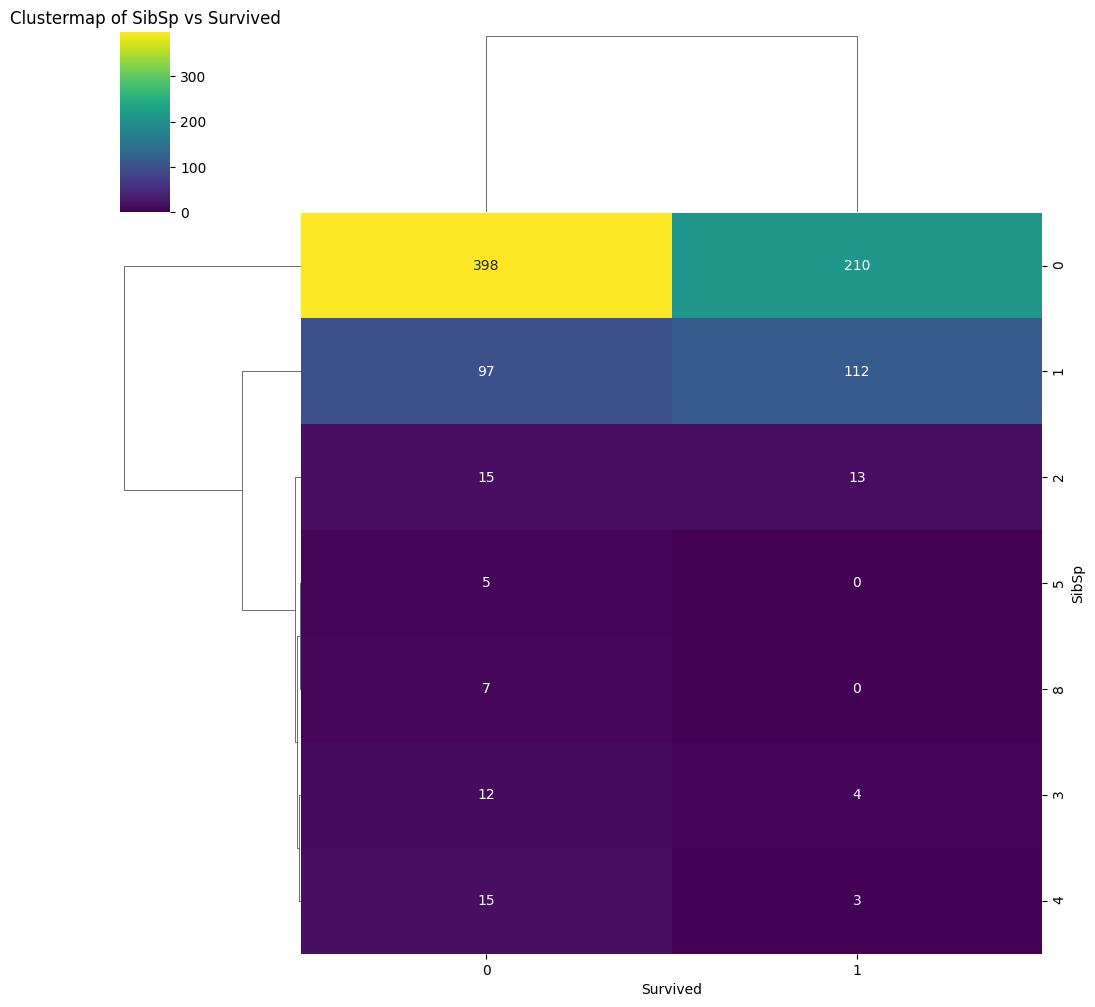

In [40]:
# Create a crosstab and display it as a clustermap
sns.clustermap(pd.crosstab(titanic['SibSp'], titanic['Survived']), cmap='viridis', annot=True, fmt="d")

plt.title("Clustermap of SibSp vs Survived")
plt.show()

#### **6. Pairplot**


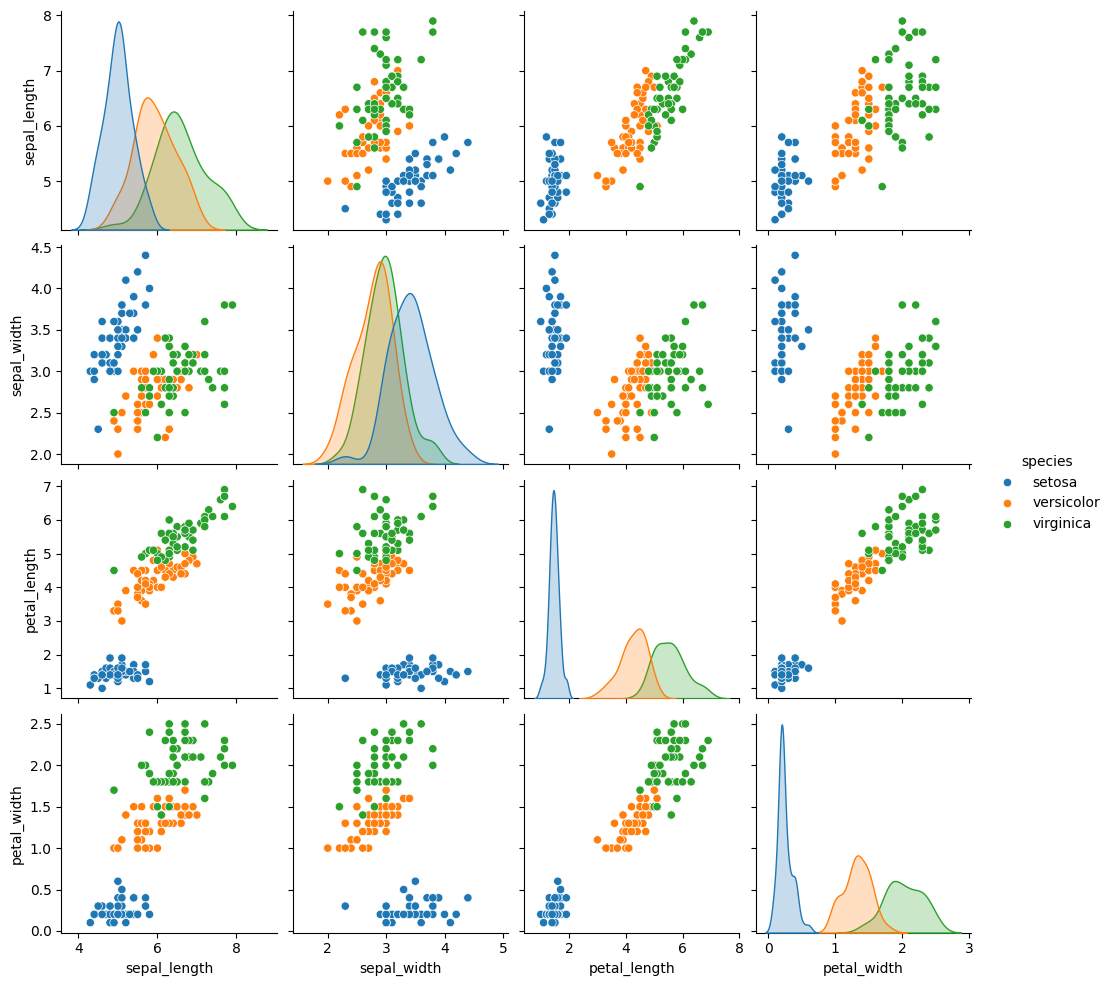

In [43]:
sns.pairplot(data=iris,hue='species')
plt.show()

#### **1. Lineplot (Numerical - Numerical)**
- Mostly for time series data

In [ ]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [48]:
new_df = flights.groupby("year").sum(numeric_only=True).reset_index()

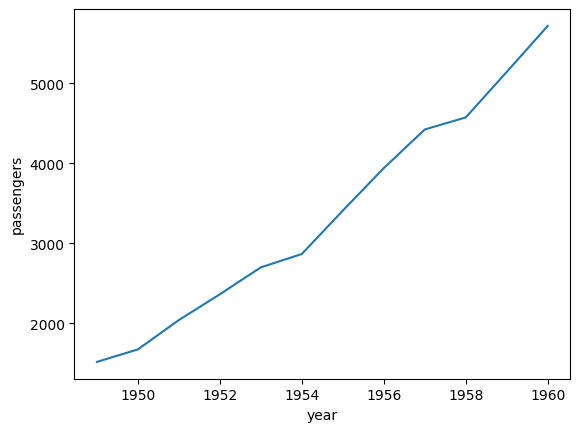

In [50]:
sns.lineplot(data=new_df,x="year",y="passengers")
plt.show()

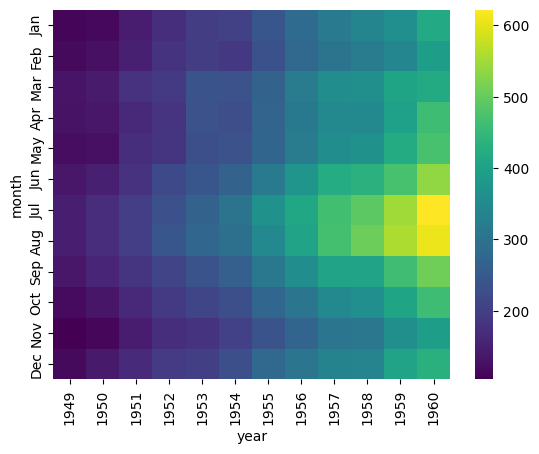

In [54]:
# heatmap on flights data
sns.heatmap(flights.pivot_table(
    values="passengers",
    index="month",
    columns="year"
), cmap='viridis')
plt.show()

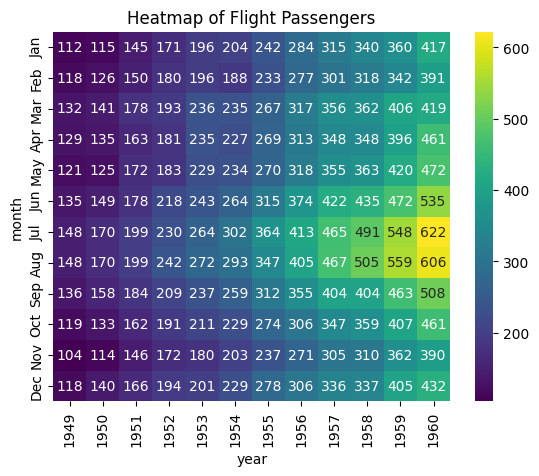

In [55]:
# Create a pivot table for the heatmap
pivot_table = flights.pivot_table(
    values="passengers",
    index="month",
    columns="year",
    fill_value=0  # Fill NaN values with 0
)

# Create the heatmap
sns.heatmap(pivot_table, cmap='viridis', annot=True, fmt=".0f")  # Use .0f for formatting

plt.title("Heatmap of Flight Passengers")
plt.show()

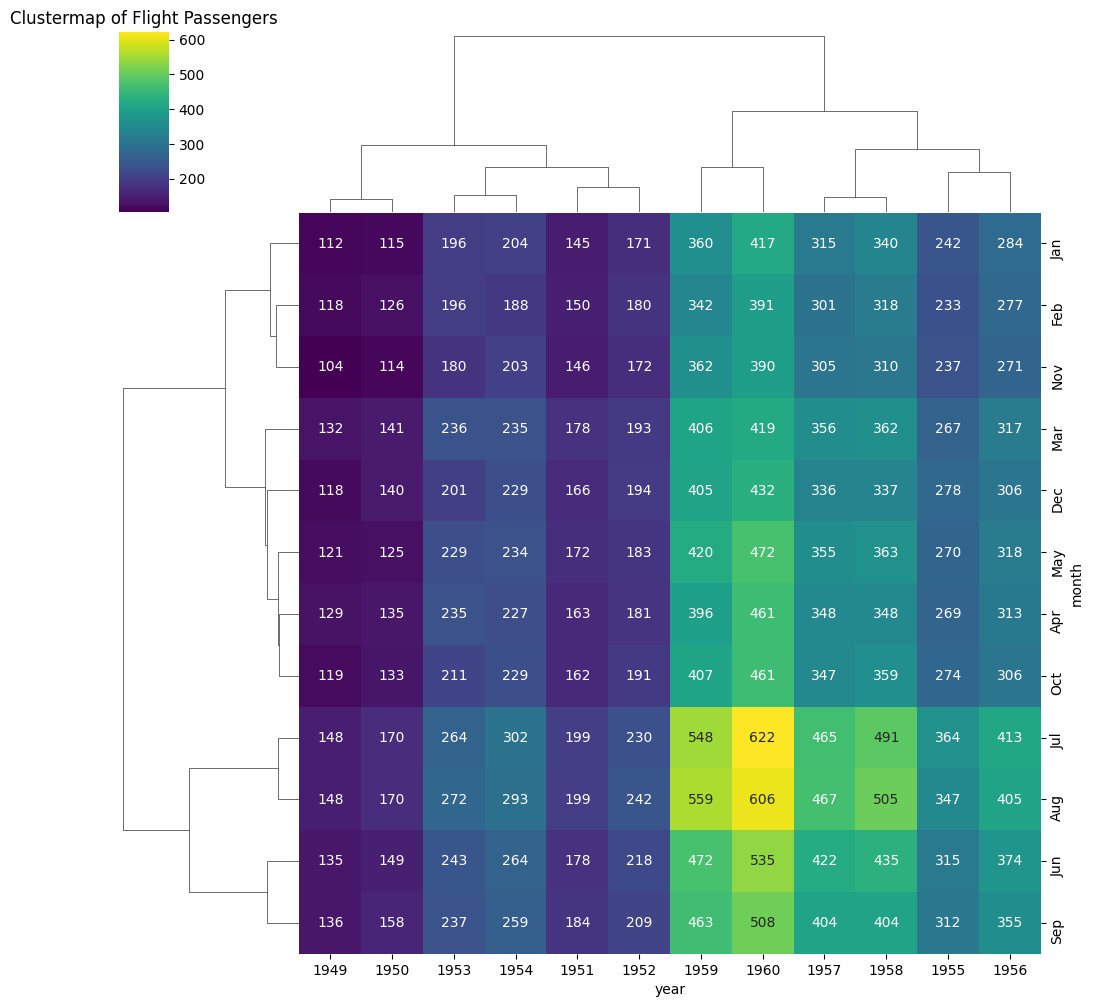

In [56]:
# Create a pivot table for the clustermap
pivot_table = flights.pivot_table(
    values="passengers",
    index="month",
    columns="year",
    fill_value=0  # Fill NaN values with 0
)

# Create the clustermap
sns.clustermap(pivot_table, cmap='viridis', annot=True, fmt=".0f")  # Use .0f for formatting

plt.title("Clustermap of Flight Passengers")
plt.show()

---